# Investigating differences in MAF and why they are happening
7.1.2025  
Ryan Doughty

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# variants = pd.read_csv('/home/Users/rdd4/intrahost_variants/investigations/variant_differences/Variant Outcomes - Variants Only.tsv', delimiter='\t')
# variants = pd.read_csv('/home/Users/rdd4/intrahost_variants/investigations/variant_differences/Variant Outcomes - Variants_SRR33673666.tsv', delimiter='\t')
variants = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/UW_results/SRR33673662_k19/variants.tsv', delimiter='\t')
# variants = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/NY_biotia/SRR23007203_clean_k19/variants.tsv', delimiter='\t')
# variants = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/benin_covid/ERR12123965_clean_k19/variants.tsv', delimiter='\t')
variants

FileNotFoundError: [Errno 2] No such file or directory: '/home/Users/rdd4/intrahost_variants/test_outputs/UW_results/SRR33673662_k19/variants.tsv'

In [346]:
# Helper to get depth, major, minor, and MAF
def compute_stats_with_counts(row, prefix):
    bases = ['A', 'C', 'G', 'T']
    counts = [row[f"{b}_{prefix}"] for b in bases]
    depth = sum(counts)
    sorted_counts = sorted(zip(bases, counts), key=lambda x: x[1], reverse=True)
    major, major_count = sorted_counts[0]
    minor, minor_count = sorted_counts[1]
    maf = minor_count / depth if depth > 0 else 0
    prefix = prefix.upper()
    return pd.Series([
        depth,
        major,
        major_count,
        minor,
        minor_count,
        maf
    ], index=[
        f'{prefix}_depth',
        f'{prefix}_major',
        f'{prefix}_major_count',
        f'{prefix}_minor',
        f'{prefix}_minor_count',
        f'{prefix}_maf'
    ])


# Compute IV stats
def get_columns(variants):
    variants = variants.join(variants.apply(compute_stats_with_counts, axis=1, prefix='iv'))
    variants = variants.join(variants.apply(compute_stats_with_counts, axis=1, prefix='bt'))

    # Compute differences
    variants['Depth Difference'] = variants['BT_depth'] - variants['IV_depth']
    variants['maf difference'] = variants['BT_maf'] - variants['IV_maf']

    # Reorder columns (optional)
    desired_order = [
        'reference', 'index', 'global_index', 'ref', 'present',
        'Depth Difference', 'maf difference',
        'IV_depth', 'IV_major', 'IV_major_count','IV_minor', 'IV_minor_count','IV_maf', 'A_iv', 'C_iv', 'G_iv', 'T_iv',
        'BT_depth', 'BT_major', 'BT_major_count','BT_minor', 'BT_minor_count', 'BT_maf', 'A_bt', 'C_bt', 'G_bt', 'T_bt'
    ]

    variants = variants[desired_order]
    return variants

In [347]:
variants = get_columns(variants)
variants

,reference,index,global_index,ref,present,Depth Difference,maf difference,IV_depth,IV_major,IV_major_count,...,BT_depth,BT_major,BT_major_count,BT_minor,BT_minor_count,BT_maf,A_bt,C_bt,G_bt,T_bt
0,PV249929.1,520,520,A,Both,1780,0.000720,17812,A,17633,...,19592,A,19350,G,211,0.010770,19350,13,211,18
1,PV249929.1,881,881,G,Both,4187,-0.003161,15390,G,15067,...,19577,G,19208,C,349,0.017827,9,349,19208,11
2,PV249929.1,1057,1057,A,Both,2396,-0.001397,17685,A,17173,...,20081,A,19518,C,492,0.024501,19518,492,69,2
3,PV249929.1,1291,1291,G,Both,5739,-0.000606,15874,G,15622,...,21613,G,21274,C,330,0.015269,6,330,21274,3
4,PV249929.1,1553,1553,A,BT,7385,0.009650,21023,A,21012,...,28408,A,28091,C,289,0.010173,28091,289,9,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,PV249936.1,1409,12619,T,Both,2313,-0.000686,9555,T,9447,...,11868,T,11734,G,126,0.010617,5,3,126,11734
83,PV249936.1,1538,12748,T,Both,1049,0.000284,12525,T,12392,...,13574,T,13403,G,148,0.010903,13,10,148,13403
84,PV249936.1,2039,13249,A,Both,787,0.000902,12571,A,12380,...,13358,A,13130,T,215,0.016095,13130,0,13,215
85,PV249936.1,2169,13379,T,Both,3985,-0.000178,16430,T,16213,...,20415,T,20124,A,266,0.013030,266,21,4,20124


In [350]:
variants[variants['BT_depth'] > 1000]['present'].value_counts()

present
Both    47
BT      39
IV       1
Name: count, dtype: int64

In [354]:
variants[(variants['BT_depth'] > 1000) & (variants['present'] == 'Both')][['reference', 'index', 'global_index', 'present', 'ref', 'maf difference','IV_minor', 'IV_minor_count', 'BT_minor', 'BT_minor_count', 'A_iv', 'C_iv', 'G_iv', 'T_iv', 'A_bt', 'C_bt', 'G_bt', 'T_bt']]

,reference,index,global_index,present,ref,maf difference,IV_minor,IV_minor_count,BT_minor,BT_minor_count,A_iv,C_iv,G_iv,T_iv,A_bt,C_bt,G_bt,T_bt
0,PV249929.1,520,520,Both,A,0.000720,G,179,G,211,17633,0,179,0,19350,13,211,18
1,PV249929.1,881,881,Both,G,-0.003161,C,323,C,349,0,323,15067,0,9,349,19208,11
2,PV249929.1,1057,1057,Both,A,-0.001397,C,458,C,492,17173,458,54,0,19518,492,69,2
3,PV249929.1,1291,1291,Both,G,-0.000606,C,252,C,330,0,252,15622,0,6,330,21274,3
9,PV249931.1,82,2847,Both,T,0.007587,C,3085,C,3527,12,3085,0,11715,14,3527,13,12785
10,PV249931.1,177,2942,Both,A,-0.000541,C,190,C,207,14294,190,12,0,16242,207,18,6
11,PV249931.1,262,3027,Both,G,-0.002635,A,4903,A,6257,4903,0,7727,0,6257,5,9954,12
12,PV249931.1,590,3355,Both,T,-0.001339,G,282,G,315,0,0,282,9792,0,14,315,11489
13,PV249931.1,639,3404,Both,T,0.007648,C,405,C,583,0,405,0,9826,4,583,8,11748
14,PV249931.1,942,3707,Both,T,0.003119,A,188,A,270,188,18,0,10687,270,36,9,12935


In [318]:
interesting = variants[(variants['IV_minor_count'] > 1.6 * variants['BT_minor_count'])][['reference', 'index', 'global_index', 'present', 'ref','IV_minor', 'IV_minor_count', 'BT_minor', 'BT_minor_count', 'A_iv', 'C_iv', 'G_iv', 'T_iv', 'A_bt', 'C_bt', 'G_bt', 'T_bt']]
interesting

,reference,index,global_index,present,ref,IV_minor,IV_minor_count,BT_minor,BT_minor_count,A_iv,C_iv,G_iv,T_iv,A_bt,C_bt,G_bt,T_bt


In [319]:
# counts = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/UW_results/SRR33673662_clean_k19/num_kmers.tsv', delimiter='\t')
# counts = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/NY_biotia/SRR23007203_clean_k19/num_kmers.tsv', delimiter='\t')
counts = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/benin_covid/ERR12123965_clean_k19/num_kmers.tsv', delimiter='\t')

filtered = variants.merge(counts, on=['reference', 'index'], how='left')
filtered['interesting'] = filtered['IV_minor_count'] > 1.6 * filtered['BT_minor_count']
filtered

,reference,index,global_index,ref_x,present,Depth Difference,maf difference,IV_depth,IV_major,IV_major_count,...,ref_y,A,C,G,T,A_r,C_r,G_r,T_r,interesting
0,OP537480.1,91,91,T,BT,54,0.040797,1000,T,1000,...,NaN,0,0,0,19,0,0,0,0,False
1,OP537480.1,92,92,G,BT,53,0.040797,1001,G,1001,...,NaN,0,0,19,0,0,0,0,0,False
2,OP537480.1,94,94,A,BT,53,0.040797,1001,A,1001,...,NaN,19,0,0,0,0,0,0,0,False
3,OP537480.1,96,96,G,BT,53,0.041746,1001,G,1001,...,NaN,0,0,19,0,0,0,0,0,False
4,OP537480.1,228,228,T,BT,2049,0.447701,2387,T,2387,...,NaN,0,3,0,19,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,OP537480.1,28934,28934,T,BT,46,0.058091,677,T,677,...,NaN,0,0,0,19,0,0,0,0,False
77,OP537480.1,28937,28937,C,BT,46,0.058091,677,C,677,...,NaN,0,19,0,0,0,0,0,0,False
78,OP537480.1,28938,28938,T,BT,46,0.058091,677,T,677,...,NaN,0,0,0,19,0,0,0,0,False
79,OP537480.1,28940,28940,G,BT,52,0.064649,675,G,675,...,NaN,0,0,19,0,0,0,0,0,False


In [320]:
filtered[filtered['interesting'] == True]

,reference,index,global_index,ref_x,present,Depth Difference,maf difference,IV_depth,IV_major,IV_major_count,...,ref_y,A,C,G,T,A_r,C_r,G_r,T_r,interesting


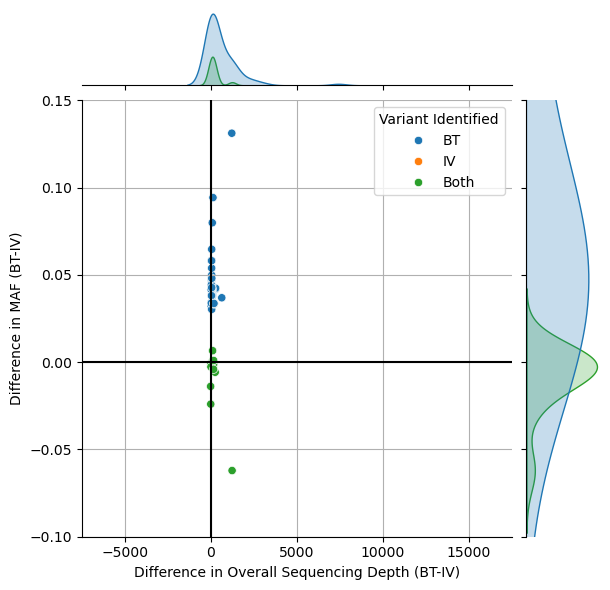

In [321]:

sns.jointplot(variants, x='Depth Difference', y='maf difference', hue='present', hue_order=['BT', 'IV', 'Both'])
plt.grid()
plt.ylabel('Difference in MAF (BT-IV)')
plt.xlabel('Difference in Overall Sequencing Depth (BT-IV)')
plt.legend(title='Variant Identified')
plt.xlim([-7500, 17500])
plt.ylim([-0.1, 0.15])
plt.axhline(0, color='black')
plt.axvline(0, color='black')


In [323]:
def abundance_plots(data): 
    fig, ax = plt.subplots(1,3, figsize=(8,8))
    sns.jointplot(variants, x='BT_maf', y='IV_maf', hue='present', hue_order=['BT', 'IV', 'Both'], ax=ax[0])
    ax[0].grid()
    ax[0].set_ylabel('IV Minor Allele Frequency')
    ax[0].set_xlabel('BT Minor Allele Frequency')
    ax[0].legend(title='Variant Identified')
    ax[0].axhline(0, color='black')
    ax[0].axvline(0, color='black')
    # now plot both limits against eachother
    ax[0].plot([0, 1], [0, 1], 'k-', alpha=0.75, zorder=0)
    ax[0].set_xlim([0, 0.5])
    ax[0].set_ylim([0, 0.5])

(0.0, 0.5)

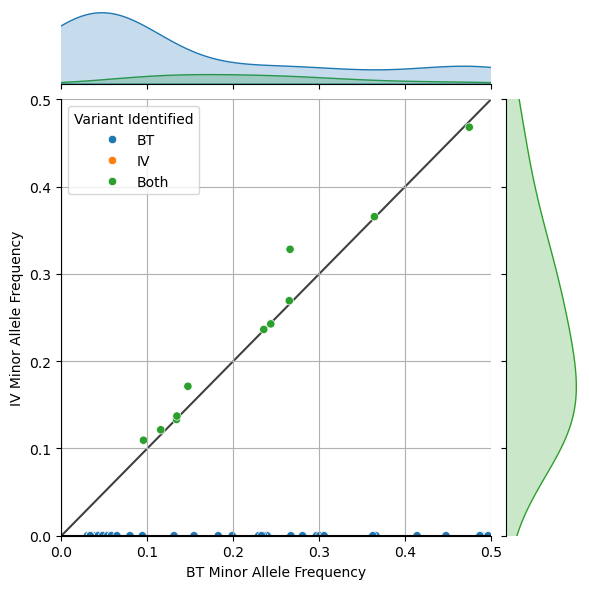

In [324]:

sns.jointplot(variants, x='BT_maf', y='IV_maf', hue='present', hue_order=['BT', 'IV', 'Both'])
plt.grid()
plt.ylabel('IV Minor Allele Frequency')
plt.xlabel('BT Minor Allele Frequency')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
# now plot both limits against eachother
plt.plot([0, 1], [0, 1], 'k-', alpha=0.75, zorder=0)
plt.xlim([0, 0.5])
plt.ylim([0, 0.5])

(0.0, 0.05)

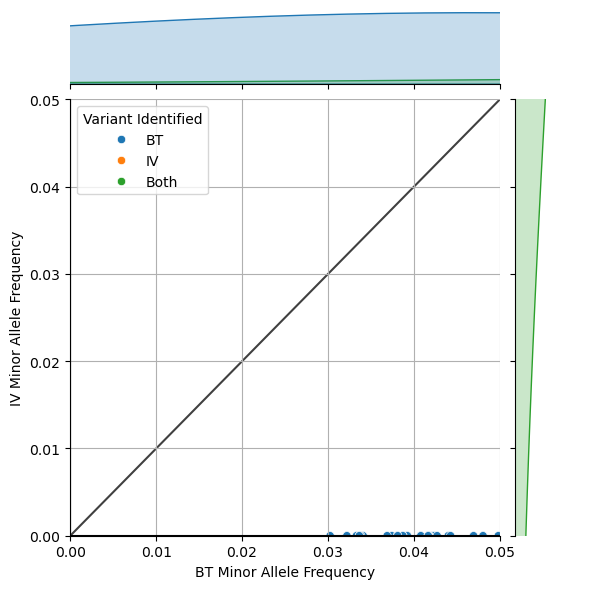

In [325]:

sns.jointplot(variants, x='BT_maf', y='IV_maf', hue='present', hue_order=['BT', 'IV', 'Both'] )
plt.grid()
plt.ylabel('IV Minor Allele Frequency')
plt.xlabel('BT Minor Allele Frequency')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
# now plot both limits against eachother
plt.plot([0, 1], [0, 1], 'k-', alpha=0.75, zorder=0)
plt.xlim([0, 0.05])
plt.ylim([0, 0.05])

(-0.003, 0.05)

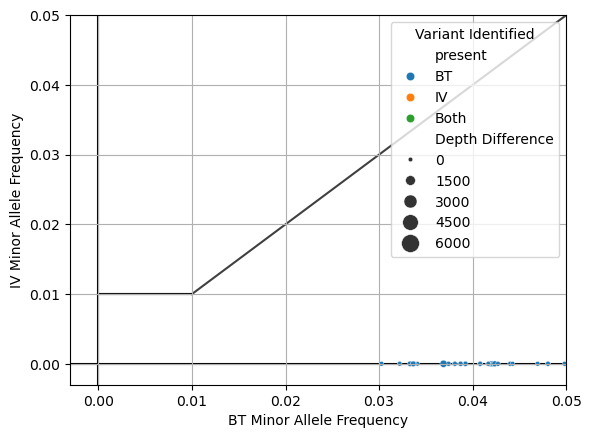

In [326]:

sns.scatterplot(variants, x='BT_maf', y='IV_maf', hue='present', size='Depth Difference', sizes=(10, 200),  hue_order=['BT', 'IV', 'Both'])
plt.grid()
plt.ylabel('IV Minor Allele Frequency')
plt.xlabel('BT Minor Allele Frequency')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.01, 1], [0.01, 1], 'k-', alpha=0.75, zorder=0)
plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 0.05])
plt.ylim([-0.003, 0.05])

(-0.003, 1000.0)

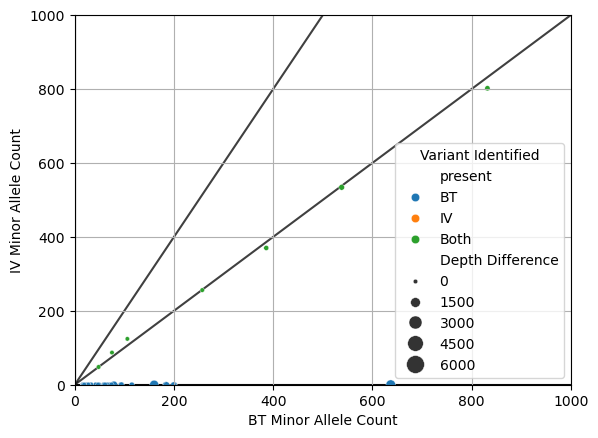

In [327]:

sns.scatterplot(variants, x='BT_minor_count', y='IV_minor_count', hue='present', size='Depth Difference', sizes=(10, 200),  hue_order=['BT', 'IV', 'Both'])
plt.grid()
plt.ylabel('IV Minor Allele Count')
plt.xlabel('BT Minor Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 7000], [0.0, 7000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 3500], [0.0, 7000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 1000])
plt.ylim([-0.003, 1000])

(-0.003, 25000.0)

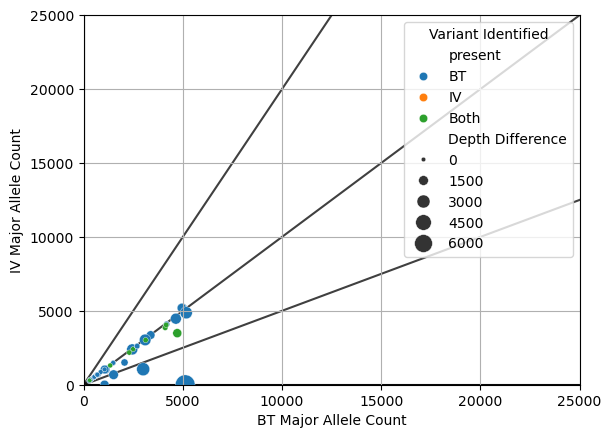

In [328]:

sns.scatterplot(variants, x='BT_major_count', y='IV_major_count', hue='present', size='Depth Difference', sizes=(10, 200), hue_order=['BT', 'IV', 'Both'])
plt.grid()
plt.ylabel('IV Major Allele Count')
plt.xlabel('BT Major Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 30000], [0.0, 30000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 15000], [0.0, 30000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 30000], [0.0, 15000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 25000])
plt.ylim([-0.003, 25000])

(-0.003, 25000.0)

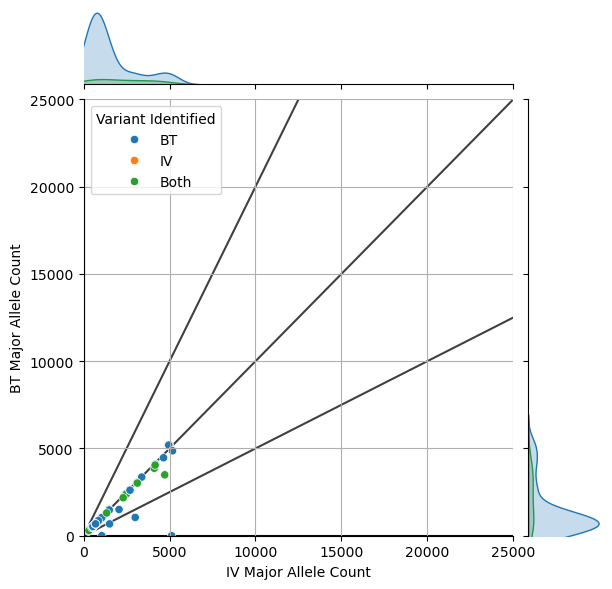

In [329]:

sns.jointplot(variants, x='BT_major_count', y='IV_major_count', hue='present', sizes=(10, 200), hue_order=['BT', 'IV', 'Both'])
plt.grid()
plt.ylabel('BT Major Allele Count')
plt.xlabel('IV Major Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 25000], [0.0, 25000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 12500], [0.0, 25000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 25000], [0.0, 12500], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 25000])
plt.ylim([-0.003, 25000])

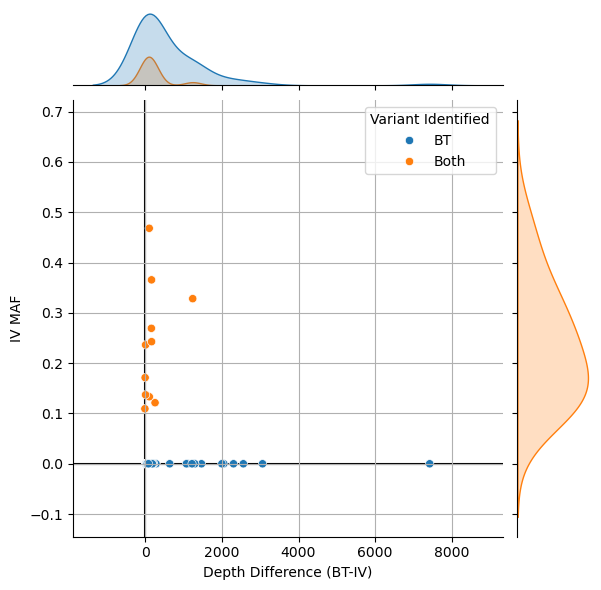

In [330]:
sns.jointplot(variants, x='Depth Difference', y='IV_maf', hue='present', sizes=(10, 200))
plt.grid()
plt.ylabel('IV MAF')
plt.xlabel('Depth Difference (BT-IV)')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
# plt.plot([0.0, 25000], [0.0, 25000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.0, 12500], [0.0, 25000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.0, 25000], [0.0, 12500], 'k-', alpha=0.75, zorder=0)
# # plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# # plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.xlim([-0.003, 25000])
# plt.ylim([-0.003, 25000])

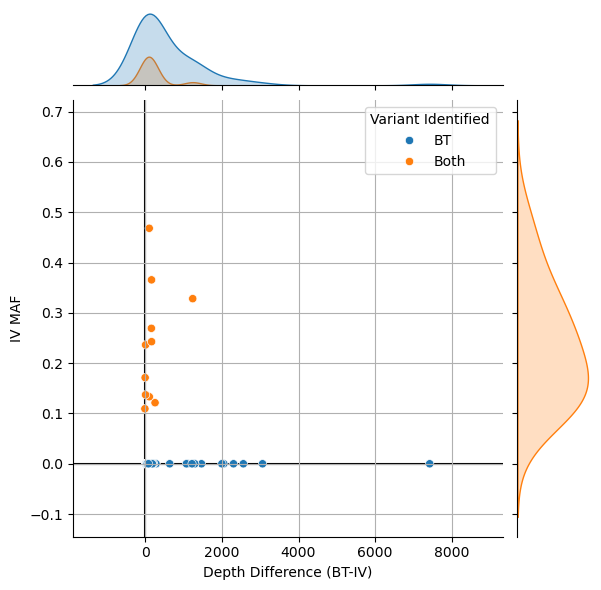

In [331]:
sns.jointplot(variants, x='Depth Difference', y='IV_maf', hue='present', sizes=(10, 200))
plt.grid()
plt.ylabel('IV MAF')
plt.xlabel('Depth Difference (BT-IV)')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)

### Looking at all sites

In [332]:
sites = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/UW_results/SRR33673663_clean_k19/counts.tsv', delimiter='\t')
sites = pd.read_csv('/home/Users/rdd4/intrahost_variants/test_outputs/benin_covid/ERR12123976_clean_k19/counts.tsv', delimiter='\t')
sites = get_columns(sites)
sites

,reference,index,global_index,ref,present,Depth Difference,maf difference,IV_depth,IV_major,IV_major_count,...,BT_depth,BT_major,BT_major_count,BT_minor,BT_minor_count,BT_maf,A_bt,C_bt,G_bt,T_bt
0,OP537480.1,20,20,C,Neither,-1567,0.000619,4796,C,4796,...,3229,C,3225,A,2,0.000619,2,3225,0,2
1,OP537480.1,21,21,A,Neither,-1575,0.003407,4804,A,4804,...,3229,A,3218,C,11,0.003407,3218,11,0,0
2,OP537480.1,22,22,A,Neither,-1584,0.000619,4815,A,4815,...,3231,A,3228,G,2,0.000619,3228,1,2,0
3,OP537480.1,23,23,C,Neither,-1599,0.000310,4820,C,4820,...,3221,C,3220,A,1,0.000310,1,3220,0,0
4,OP537480.1,24,24,C,Neither,-1602,0.000928,4834,C,4834,...,3232,C,3228,A,3,0.000928,3,3228,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29808,OP537480.1,29828,29828,NaN,Neither,0,0.000000,0,A,0,...,0,A,0,C,0,0.000000,0,0,0,0
29809,OP537480.1,29829,29829,NaN,Neither,0,0.000000,0,A,0,...,0,A,0,C,0,0.000000,0,0,0,0
29810,OP537480.1,29830,29830,NaN,Neither,0,0.000000,0,A,0,...,0,A,0,C,0,0.000000,0,0,0,0
29811,OP537480.1,29831,29831,NaN,Neither,0,0.000000,0,A,0,...,0,A,0,C,0,0.000000,0,0,0,0


(-0.003, 60000.0)

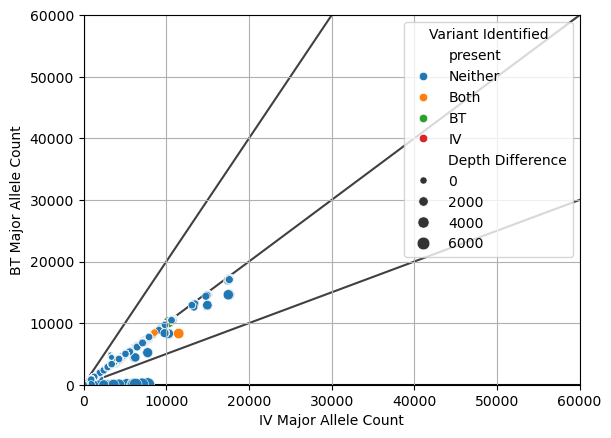

In [333]:

sns.scatterplot(sites, x='BT_major_count', y='IV_major_count', hue='present', size='Depth Difference', sizes=(10, 100))
plt.grid()
plt.ylabel('BT Major Allele Count')
plt.xlabel('IV Major Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 100000], [0.0, 100000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 50000], [0.0, 100000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 100000], [0.0, 50000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 60000])
plt.ylim([-0.003, 60000])

(-0.003, 60000.0)

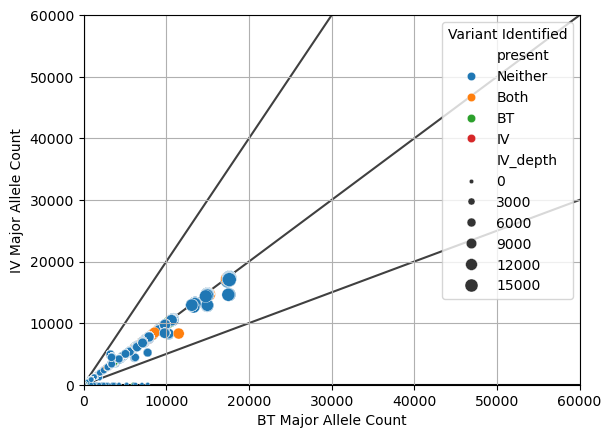

In [334]:

sns.scatterplot(sites, x='BT_major_count', y='IV_major_count', hue='present', size='IV_depth', sizes=(10, 100))
plt.grid()
plt.ylabel('IV Major Allele Count')
plt.xlabel('BT Major Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 100000], [0.0, 100000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 50000], [0.0, 100000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 100000], [0.0, 50000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 60000])
plt.ylim([-0.003, 60000])

(-0.003, 60000.0)

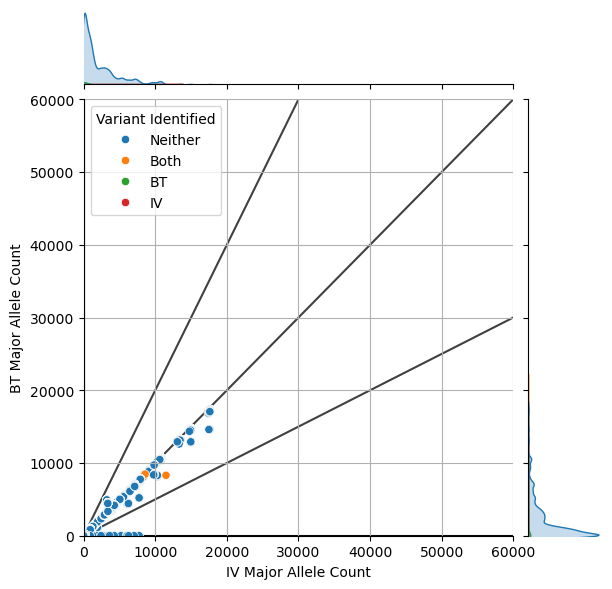

In [335]:
sns.jointplot(sites, x='BT_major_count', y='IV_major_count', hue='present')
plt.grid()
plt.ylabel('BT Major Allele Count')
plt.xlabel('IV Major Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 100000], [0.0, 100000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 50000], [0.0, 100000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 100000], [0.0, 50000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 60000])
plt.ylim([-0.003, 60000])

(-0.003, 1000.0)

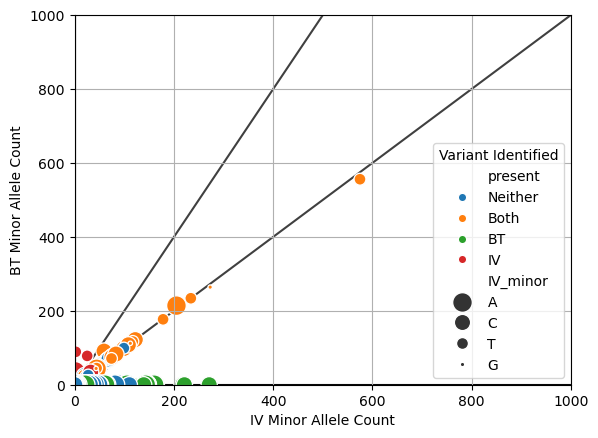

In [336]:

sns.scatterplot(sites, x='BT_minor_count', y='IV_minor_count', hue='present', size='IV_minor', sizes=(10, 200))
plt.grid()
plt.ylabel('BT Minor Allele Count')
plt.xlabel('IV Minor Allele Count')
plt.legend(title='Variant Identified')
plt.axhline(0, color='black', zorder=0)
plt.axvline(0, color='black', zorder=0)
# now plot both limits against eachother
plt.plot([0.0, 1000], [0.0, 1000], 'k-', alpha=0.75, zorder=0)
plt.plot([0.0, 500], [0.0, 1000], 'k-', alpha=0.75, zorder=0)
# plt.plot([0, 0.01], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
# plt.plot([0.01, 0], [0.01, 0.01], 'k-', alpha=0.75, zorder=0)
plt.xlim([-0.003, 1000])
plt.ylim([-0.003, 1000])

In [337]:
num_kmers = sites.merge(counts, on=['reference', 'index'], how='left')
# Ensure relevant columns are numeric
for col in ['A', 'C', 'G', 'T', 'A_r', 'C_r', 'G_r', 'T_r']:
    num_kmers[col] = pd.to_numeric(num_kmers[col], errors='coerce').fillna(0)

# Row-wise sums
num_kmers['kmers_forward'] = num_kmers[['A', 'C', 'G', 'T']].sum(axis=1)
num_kmers['kmers_rev'] = num_kmers[['A_r', 'C_r', 'G_r', 'T_r']].sum(axis=1)

# Final total
num_kmers['num_kmers'] = num_kmers['kmers_forward'] + num_kmers['kmers_rev']
num_kmers['kmer_diff'] = np.abs(num_kmers['kmers_forward'] - num_kmers['kmers_rev'])


In [338]:
num_kmers

,reference,index,global_index,ref_x,present,Depth Difference,maf difference,IV_depth,IV_major,IV_major_count,...,G,T,A_r,C_r,G_r,T_r,kmers_forward,kmers_rev,num_kmers,kmer_diff
0,OP537480.1,20,20,C,Neither,-1567,0.000619,4796,C,4796,...,0,1,0,0,0,0,20,0,20,20
1,OP537480.1,21,21,A,Neither,-1575,0.003407,4804,A,4804,...,0,0,0,0,0,0,19,0,19,19
2,OP537480.1,22,22,A,Neither,-1584,0.000619,4815,A,4815,...,0,0,0,0,0,0,20,0,20,20
3,OP537480.1,23,23,C,Neither,-1599,0.000310,4820,C,4820,...,0,0,0,0,0,0,20,0,20,20
4,OP537480.1,24,24,C,Neither,-1602,0.000928,4834,C,4834,...,0,0,0,0,0,0,19,0,19,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29808,OP537480.1,29828,29828,NaN,Neither,0,0.000000,0,A,0,...,0,0,0,0,0,0,0,0,0,0
29809,OP537480.1,29829,29829,NaN,Neither,0,0.000000,0,A,0,...,0,0,0,0,0,0,0,0,0,0
29810,OP537480.1,29830,29830,NaN,Neither,0,0.000000,0,A,0,...,0,0,0,0,0,0,0,0,0,0
29811,OP537480.1,29831,29831,NaN,Neither,0,0.000000,0,A,0,...,0,0,0,0,0,0,0,0,0,0


In [339]:
def add_rolling_averages(df, value_cols, window_size, extra_label=''):
    half_window = window_size // 2
    all_results = []

    for ref, group in df.groupby("reference", sort=False):
        group = group.sort_values("index").reset_index(drop=True)
        indexes = group["index"].values

        rolling_values = {col: [] for col in value_cols}

        for i, idx in enumerate(indexes):
            lower = idx - half_window
            upper = idx + half_window
            window = group[(group["index"] >= lower) & (group["index"] <= upper)]

            for col in value_cols:
                rolling_values[col].append(window[col].mean())

        # Add rolling average columns
        for col in value_cols:
            group[f"{col}_rolling_avg{extra_label}"] = rolling_values[col]

        all_results.append(group)

    return pd.concat(all_results, ignore_index=True)


In [340]:
def shannon_entropy(row, bases=['A', 'C', 'G', 'T']):
    counts = np.array([row[b] for b in bases])
    total = counts.sum()
    if total == 0:
        return 0
    freqs = counts / total
    freqs = freqs[freqs > 0]  # avoid log(0)
    return -np.sum(freqs * np.log2(freqs))

def normalized_shannon_entropy(row, bases=['A', 'C', 'G', 'T']):
    counts = np.array([row[b] for b in bases])
    depth = row['IV_depth']
    if depth == 0:
        return 0
    freqs = counts / depth
    freqs = freqs[freqs > 0]
    h_obs = -np.sum(freqs * np.log2(freqs))
    h_max = np.log2(min(4, depth))
    return h_obs / h_max if h_max > 0 else 0

# Apply to DataFrame
num_kmers['entropy_forward'] = num_kmers.apply(lambda row: normalized_shannon_entropy(row, ['A', 'C', 'G', 'T']), axis=1)
num_kmers['entropy_reverse'] = num_kmers.apply(lambda row: normalized_shannon_entropy(row, ['A_r', 'C_r', 'G_r', 'T_r']), axis=1)
num_kmers['entropy_mean'] = num_kmers[['entropy_forward', 'entropy_reverse']].mean(axis=1)

In [341]:
num_kmers = add_rolling_averages(num_kmers, ['num_kmers', 'kmers_forward', 'kmers_rev', 'entropy_forward', 'entropy_reverse', 'entropy_mean'], 50)
num_kmers = add_rolling_averages(num_kmers, ['entropy_forward', 'entropy_reverse', 'entropy_mean'], 250, '_long')

In [342]:
num_kmers['rolling_kmer_diff'] = num_kmers['kmers_forward_rolling_avg'] - num_kmers['kmers_rev_rolling_avg']
num_kmers['entropy_local'] = num_kmers['entropy_mean_rolling_avg'] - num_kmers['entropy_mean_rolling_avg_long']
# num_kmers['entropy_local_reverse'] = num_kmers['entropy_reverse_rolling_avg'] - num_kmers['entropy_reverse_rolling_avg_long']
num_kmers

,reference,index,global_index,ref_x,present,Depth Difference,maf difference,IV_depth,IV_major,IV_major_count,...,kmers_forward_rolling_avg,kmers_rev_rolling_avg,entropy_forward_rolling_avg,entropy_reverse_rolling_avg,entropy_mean_rolling_avg,entropy_forward_rolling_avg_long,entropy_reverse_rolling_avg_long,entropy_mean_rolling_avg_long,rolling_kmer_diff,entropy_local
0,OP537480.1,20,20,C,Neither,-1567,0.000619,4796,C,4796,...,20.730769,0.0,0.016936,0.0,0.008468,0.020241,0.0,0.010120,20.730769,-0.001652
1,OP537480.1,21,21,A,Neither,-1575,0.003407,4804,A,4804,...,20.740741,0.0,0.016926,0.0,0.008463,0.020253,0.0,0.010126,20.740741,-0.001663
2,OP537480.1,22,22,A,Neither,-1584,0.000619,4815,A,4815,...,20.857143,0.0,0.016985,0.0,0.008493,0.020264,0.0,0.010132,20.857143,-0.001639
3,OP537480.1,23,23,C,Neither,-1599,0.000310,4820,C,4820,...,20.862069,0.0,0.016974,0.0,0.008487,0.020276,0.0,0.010138,20.862069,-0.001651
4,OP537480.1,24,24,C,Neither,-1602,0.000928,4834,C,4834,...,20.866667,0.0,0.016964,0.0,0.008482,0.020287,0.0,0.010144,20.866667,-0.001662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29808,OP537480.1,29828,29828,NaN,Neither,0,0.000000,0,A,0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
29809,OP537480.1,29829,29829,NaN,Neither,0,0.000000,0,A,0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
29810,OP537480.1,29830,29830,NaN,Neither,0,0.000000,0,A,0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
29811,OP537480.1,29831,29831,NaN,Neither,0,0.000000,0,A,0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [343]:
def compute_entropy_slope(df, entropy_col='entropy_mean_rolling_avg_long'):
    results = []

    for ref, group in df.groupby('reference'):
        group = group.sort_values('index').reset_index(drop=True)

        # Extract index and entropy as arrays
        x = group['index'].values
        y = group[entropy_col].values

        # Compute gradient using index as spacing
        grad = np.gradient(y, x)

        # Normalize by magnitude of entropy (avoid divide-by-zero)
        norm_grad = grad / np.abs(y)
        norm_grad = np.nan_to_num(norm_grad, nan=0.0, posinf=0.0, neginf=0.0)

        group['entropy_gradient'] = grad
        group['entropy_gradient_norm'] = norm_grad

        results.append(group)

    return pd.concat(results, ignore_index=True)

num_kmers = compute_entropy_slope(num_kmers)
num_kmers = add_rolling_averages(num_kmers, ['entropy_gradient_norm'], 19)

/tmp/ipykernel_1374578/1446382603.py:15: RuntimeWarning: divide by zero encountered in divide
  norm_grad = grad / np.abs(y)
/tmp/ipykernel_1374578/1446382603.py:15: RuntimeWarning: invalid value encountered in divide
  norm_grad = grad / np.abs(y)


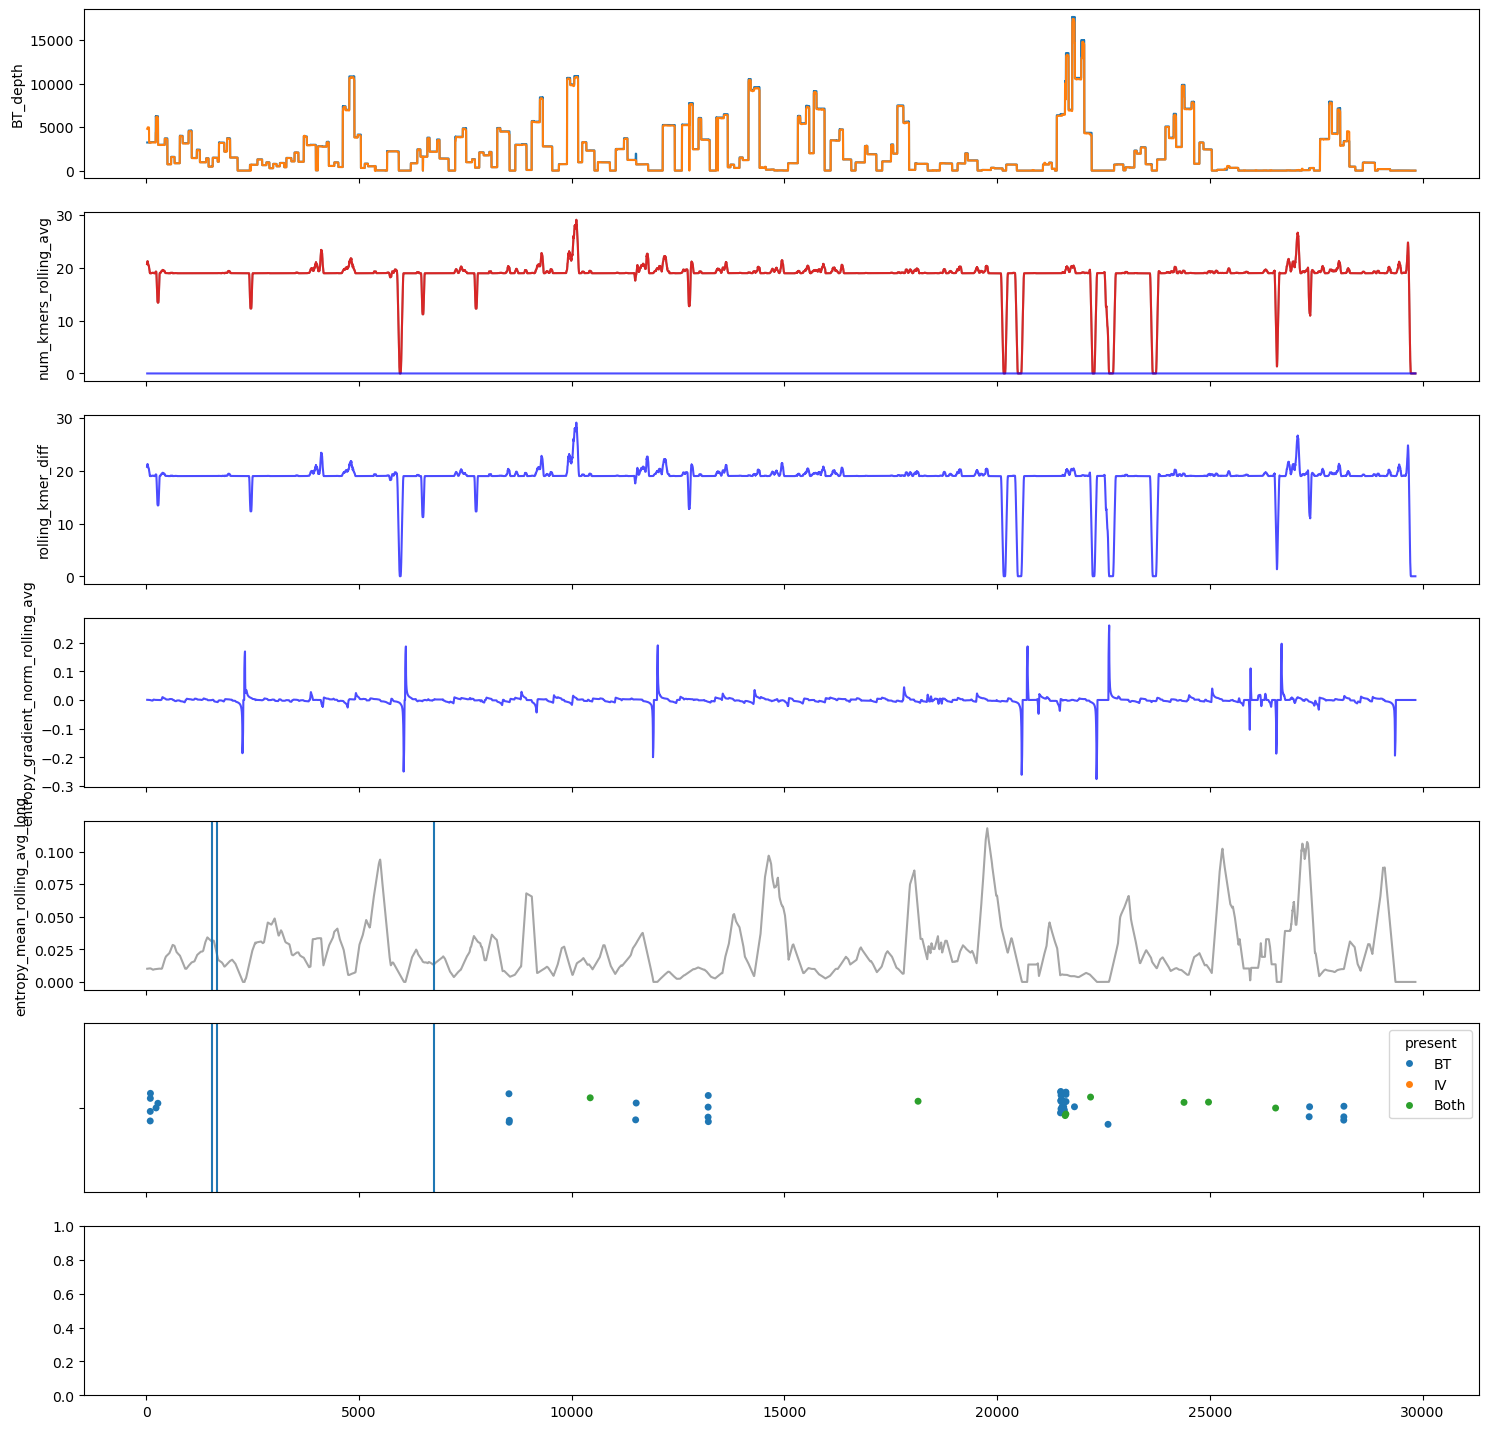

In [344]:
fig, ax = plt.subplots(7, 1, sharex=True, figsize=(18, 18))
sns.lineplot(num_kmers, x='global_index', y='BT_depth', ax=ax[0])
sns.lineplot(num_kmers, x='global_index', y='IV_depth', ax=ax[0])
sns.lineplot(num_kmers, x='global_index', y='num_kmers_rolling_avg', ax=ax[1], color='gray')
sns.lineplot(num_kmers, x='global_index', y='kmers_forward_rolling_avg', ax=ax[1], color='red', alpha=0.7)
sns.lineplot(num_kmers, x='global_index', y='kmers_rev_rolling_avg', ax=ax[1], color='blue', alpha=0.7)
sns.lineplot(num_kmers, x='global_index', y='rolling_kmer_diff', ax=ax[2], color='blue', alpha=0.7)
# sns.lineplot(num_kmers, x='global_index', y='entropy_forward_rolling_avg', ax=ax[3], color='red', alpha=0.7)
sns.lineplot(num_kmers, x='global_index', y='entropy_gradient_norm_rolling_avg', ax=ax[3], color='blue', alpha=0.7)
# sns.lineplot(num_kmers, x='global_index', y='entropy_reverse_rolling_avg_long', ax=ax[4], color='red', alpha=0.7)
# sns.lineplot(num_kmers, x='global_index', y='entropy_forward_rolling_avg_long', ax=ax[4], color='blue', alpha=0.7)
sns.lineplot(num_kmers, x='global_index', y='entropy_mean_rolling_avg_long', ax=ax[4], color='gray', alpha=0.7)
ax[4].axvline(x=6763)
ax[4].axvline(x=1553)
ax[4].axvline(x=1657)
# sns.lineplot(num_kmers, x='global_index', y='entropy_local_reverse', ax=ax[4], color='blue', alpha=0.7)
sns.stripplot(variants[variants['BT_depth']>1000], x='global_index', hue='present', ax=ax[5], hue_order=['BT', 'IV', 'Both'])
sns.stripplot(interesting, x='global_index', hue='present', ax=ax[6], hue_order=['BT', 'IV', 'Both'])
ax[5].axvline(x=6763)
ax[5].axvline(x=1553)
ax[5].axvline(x=1657)
